# $^{14}$N( $^{17}$F, $^{18}$Ne)$^{13}$C transfer reaction

We will use the [transfer input file from the fresco website](https://www.fresco.org.uk/examples/B5-example-tr.in) as a template.

In this reaction, a proton from $^{14}$N is transfered to $^{17}$F, to give $^{18}$Ne, leaving a residual $^{13}$C nucleus. From the [Fresco website](https://www.fresco.org.uk/guide/fresco-starting.pdf):

> Transfer reactions are often used to extract structure information to input in astrophysical simulations. Here we
consider the 14N(17F,18Ne)13C transfer reaction at 10 MeV per nucleon. This reaction was measured with the
aim of extracting the asymptotic normalization coefficient of specific states in 18Ne which in turn provides a
significant part of the rate for 17F(p,γ). The proton capture reaction on 17F appears in the rp-process in novae
environments. The ratio of the proton capture rate and the decay rate of 17F is also very important for the
understanding of galactic 17O, 18O and 15N. 


The interactions involved are:
- the entrance channel interaction between $^{14}$N and  $^{17}$F,
- the exit channel interaction between $^{18}$Ne and $^{13}$C,
- the binding potential for the single $p$ in $^{17}$F,
- the binding potential for the single $p$ in $^{13}$C,
- the core-core potential between $^{17}$F and $^{13}$C,

We will compare to experimental data from [EXFOR Entry C1137](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=2507&subID=121137003&plus=1), which was measured at Oak Ridge National Laboratory and first [reported in the literature in 2004](https://www.sciencedirect.com/science/article/pii/S0375947404010188?via%3Dihub)

In [9]:
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import inspect
import pandas as pd
import json

from tqdm import tqdm

with open("MatplotlibEsthetics.json", "r") as fptr:
    esthetics = json.load(fptr)

plt.style.use(esthetics["style"])
FONTSIZE = esthetics["fontsize"]
TICK_FONTSIZE = esthetics["tick_fontsize"]
MARKERSIZE = esthetics["markersize"]
LINEWIDTH = esthetics["linewidth"]

In [10]:
import bfrescox

In [11]:
EXAMPLE_DIR = Path("./Transfer_template/")
TEMPLATE_FILE_PATH = Path("./Transfer_template/B5-example-tr.template")
INPUT_FILE_PATH = Path("./Transfer_template/B5-example-tr.in")

## Let's run the input file exactly as is from the website

In [12]:
with open(INPUT_FILE_PATH, "r") as temp:
    input_file = temp.read()

print("Frescox input file from https://www.fresco.org.uk/examples/B5-example-tr.in:")
print("-----------------------------------")
print(input_file)

Frescox input file from https://www.fresco.org.uk/examples/B5-example-tr.in:
-----------------------------------
n14(f17,ne18)c13 @ 170 MeV; 
NAMELIST
 &FRESCO hcm=0.03 rmatch=40 rintp=0.20 hnl=0.1 rnl=5.00 centre=0.0 
	 jtmin=0.0  jtmax=120 absend=-1.0
	 thmin=0.00 thmax=40.00 thinc=0.10
	 iter=1 nnu=36
	 chans=1 xstabl=1 
	 elab=170.0  /

 &PARTITION namep='f17'  massp=17. zp=9 namet='n14'  masst=14. zt=7 nex=1  /
 &STATES jp=2.5 bandp=1 ep=0.0 cpot=1 jt=1.0 bandt=1 et=0.0000  /

 &PARTITION namep='ne18' massp=18. zp=10 namet='c13'  masst=13. zt=6 qval=3.6286 nex=1  /
 &STATES jp=0. bandp=1 ep=0.0  cpot=2 jt=0.5 bandt=1 et=0.0000  /
 &partition /

 &POT kp=1 ap=17.000 at=14.000 rc=1.3  /
 &POT kp=1 type=1 p1=37.2 p2=1.2 p3=0.6  p4=21.6 p5=1.2 p6=0.69  /

 &POT kp=2 ap=18.000 at=13.000 rc=1.3  /
 &POT kp=2 type=1 p1=37.2 p2=1.2 p3=0.6  p4=21.6 p5=1.2 p6=0.69  /

 &POT kp=3 at=17 rc=1.2  /
 &POT kp=3 type=1 p1=50.00 p2=1.2 p3=0.65   /
 &POT kp=3 type=3 p1=6.00  p2=1.2 p3=0.65   /

 &PO

In [13]:
# Create the frescox input file by filling in the user-defined template with parameters
cfg = bfrescox.Configuration.from_template(
    INPUT_FILE_PATH,
    EXAMPLE_DIR.joinpath("frescox.in"),
    {},
    overwrite=True,
)

In [14]:
%%time
bfrescox.run_simulation(
    cfg, EXAMPLE_DIR.joinpath("frescox.out"), cwd=EXAMPLE_DIR, overwrite=True
)

CPU times: user 1.61 ms, sys: 1.82 ms, total: 3.42 ms
Wall time: 4.51 s


In [15]:
results = bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
results.keys()

dict_keys(['channel_1', 'channel_2'])

Text(0, 0.5, '$d\\sigma/d\\Omega$ [mb/Sr]')

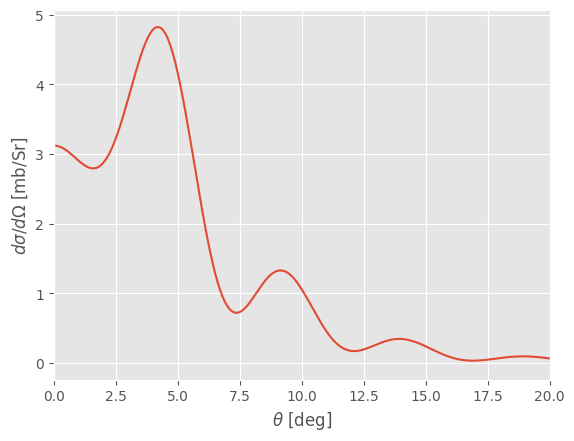

In [16]:
plt.plot(
    results["channel_2"]["Theta_deg"],
    results["channel_2"]["sigma_mb_sr"],
    label="Frescox",
)

plt.xlim([0, 20])
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [mb/Sr]")

## Now let's look at the template and see how to change the parameters

The template is the same as the input file we just ran, but we've replaced the values of the interaction parameters with keys like `@rC_entrance@`:

In [17]:
with open(TEMPLATE_FILE_PATH, "r") as temp:
    template_file = temp.read()

print("Frescox Transfer Template:")
print("-----------------------------------")
print(template_file)

Frescox Transfer Template:
-----------------------------------
n14(f17,ne18)c13 @ 170 MeV; 
NAMELIST
 &FRESCO hcm=0.03 rmatch=40 rintp=0.20 hnl=0.1 rnl=5.00 centre=0.0 
	 jtmin=0.0  jtmax=120 absend=-1.0
	 thmin=0.00 thmax=40.00 thinc=0.10
	 iter=1 nnu=36
	 chans=1 xstabl=1 
	 elab=170.0  /

 &PARTITION namep='f17'  massp=17. zp=9 namet='n14'  masst=14. zt=7 nex=1  /
 &STATES jp=2.5 bandp=1 ep=0.0 cpot=1 jt=1.0 bandt=1 et=0.0000  /

 &PARTITION namep='ne18' massp=18. zp=10 namet='c13'  masst=13. zt=6 qval=3.6286 nex=1  /
 &STATES jp=0. bandp=1 ep=0.0  cpot=2 jt=0.5 bandt=1 et=0.0000  /
 &partition /

 &POT kp=1 ap=17.000 at=14.000 rc=@rC_entrance@  /
 &POT kp=1 type=1 p1=@V_entrance@ p2=@r_entrance@ p3=@a_entrance@  p4=@W_entrance@ p5=@rw_entrance@ p6=@aw_entrance@  /

 &POT kp=2 ap=18.000 at=13.000  rc=@rC_exit@  /
 &POT kp=2 type=1 p1=@V_exit@ p2=@r_exit@ p3=@a_exit@  p4=@W_exit@ p5=@rw_exit@ p6=@aw_exit@  /

 &POT kp=3 at=17 rc=@rC_p17F@  /
 &POT kp=3 type=1 p1=@V_p17F@ p2=@r_p17F@ 

Here are the parameters from the example:

In [18]:
base_params = {
    "rC_entrance": 1.3,
    "V_entrance": 37.2,
    "r_entrance": 1.2,
    "a_entrance": 0.6,
    "W_entrance": 21.6,
    "rw_entrance": 1.2,
    "aw_entrance": 0.69,
    "rC_exit": 1.3,
    "V_exit": 37.2,
    "r_exit": 1.2,
    "a_exit": 0.6,
    "W_exit": 21.6,
    "rw_exit": 1.2,
    "aw_exit": 0.69,
    "rC_p17F": 1.2,
    "V_p17F": 50,
    "r_p17F": 1.2,
    "a_p17F": 0.65,
    "Vso_p17F": 6,
    "rso_p17F": 1.2,
    "aso_p17F": 0.65,
    "rC_p13C": 1.2,
    "V_p13C": 50,
    "r_p13C": 1.2,
    "a_p13C": 0.65,
    "Vso_p13C": 6,
    "rso_p13C": 1.2,
    "aso_p13C": 0.65,
    "rC_17F_13C": 1.3,
    "V_17F_13C": 37.2,
    "r_17F_13C": 1.2,
    "a_17F_13C": 0.6,
    "W_17F_13C": 21.6,
    "rw_17F_13C": 1.2,
    "aw_17F_13C": 0.69,
    "BE_p_17F": 3.922,
    "BE_p_13C": 7.5506,
}

In [19]:
# Create the frescox input file by filling in the user-defined template with parameters
cfg = bfrescox.Configuration.from_template(
    TEMPLATE_FILE_PATH,
    EXAMPLE_DIR.joinpath("frescox.in"),
    base_params,
    overwrite=True,
)

In [20]:
bfrescox.run_simulation(
    cfg, EXAMPLE_DIR.joinpath("frescox.out"), cwd=EXAMPLE_DIR, overwrite=True
)

In [21]:
results = bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
display(results["channel_1"].head())

,Theta_deg,sigma_mb_sr
0,0.01,1.0000
1,0.10,1.0000
2,0.20,0.9991
3,0.30,1.0010
4,0.40,1.0020


And we get the same thing:

Text(0, 0.5, '$d\\sigma/d\\Omega$ [mb/Sr]')

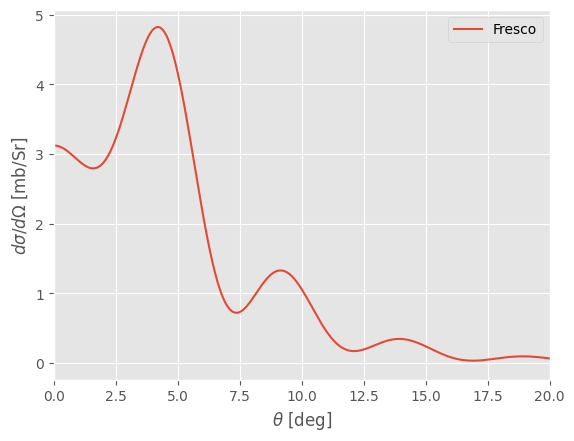

In [22]:
plt.plot(
    results["channel_2"]["Theta_deg"],
    results["channel_2"]["sigma_mb_sr"],
    label="Fresco",
)
plt.legend()
plt.xlim([0, 20])
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [mb/Sr]")

## Testing optical model parameter dependence

We can now run an ensemble of calculations with different parameters, and compare how they change the cross section. There are many different parameters in this calculation, so let's focus on just the p + $^{17}F$ interaction, but you can try perturbing other parameters yourself!

In [23]:
params_to_perturb = {
    "rC_p17F": [1.0, 1.2, 1.4],
    "V_p17F": [40, 50, 60],
    "r_p17F": [1.0, 1.2, 1.4],
    "a_p17F": [0.5, 0.65, 0.8],
    "Vso_p17F": [4, 8, 12],
    "rso_p17F": [1.0, 1.2, 1.4],
    "aso_p17F": [0.5, 0.65, 0.8],
}

In [24]:
results = {}
for param_name, values in tqdm(params_to_perturb.items()):
    results[param_name] = []
    for val in values:
        params = base_params.copy()
        params[param_name] = val
        cfg = bfrescox.Configuration.from_template(
            TEMPLATE_FILE_PATH,
            EXAMPLE_DIR.joinpath("frescox.in"),
            params,
            overwrite=True,
        )
        bfrescox.run_simulation(
            cfg, EXAMPLE_DIR.joinpath("frescox.out"), cwd=EXAMPLE_DIR, overwrite=True
        )
        results[param_name].append(
            bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
        )

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:36<00:00, 13.72s/it]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 45.03it/s]


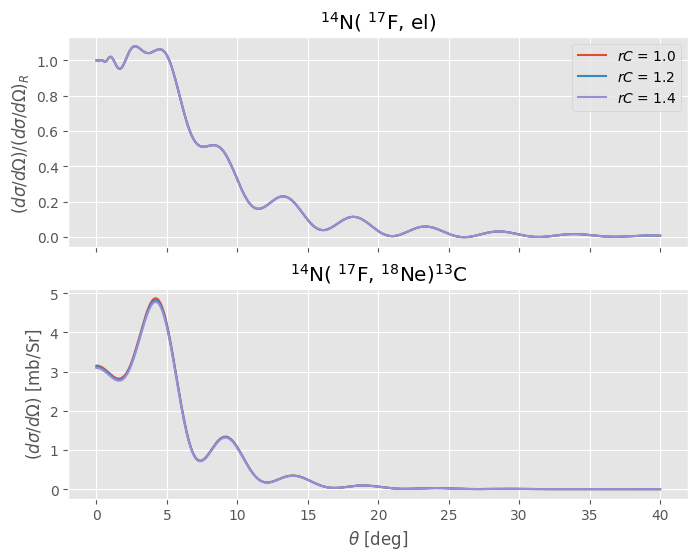

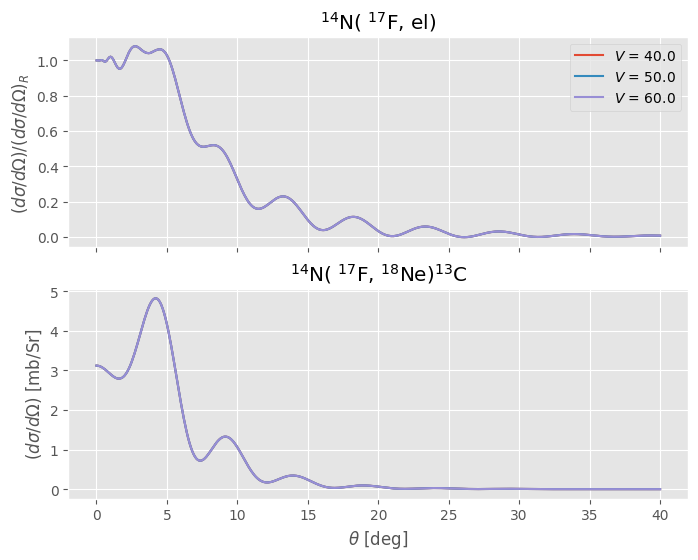

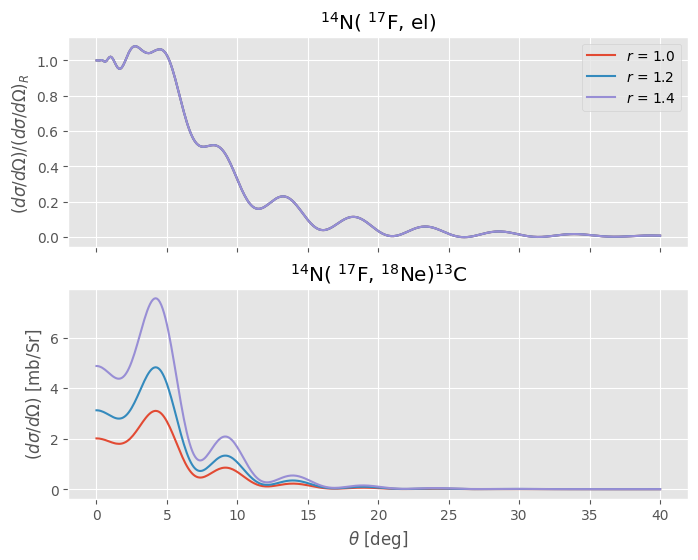

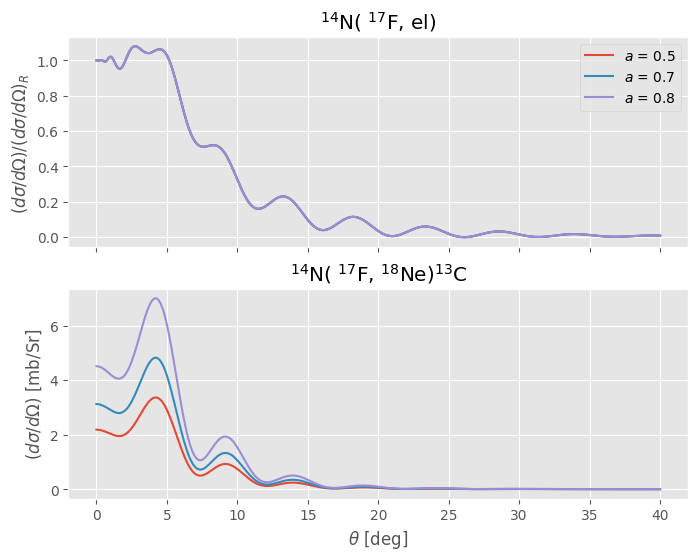

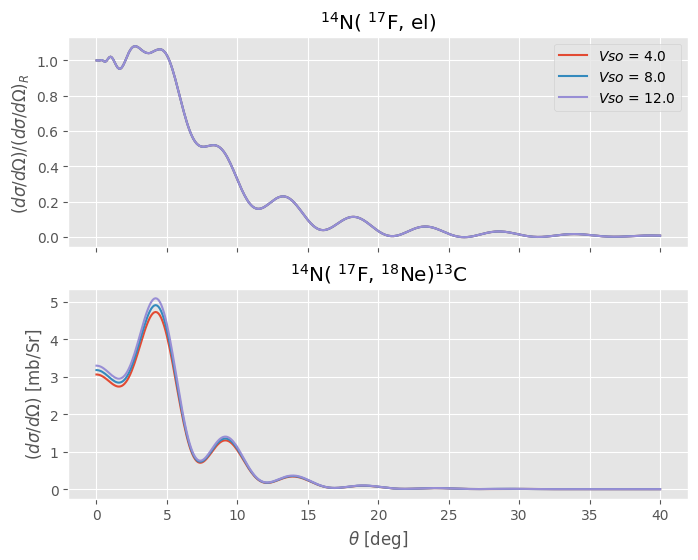

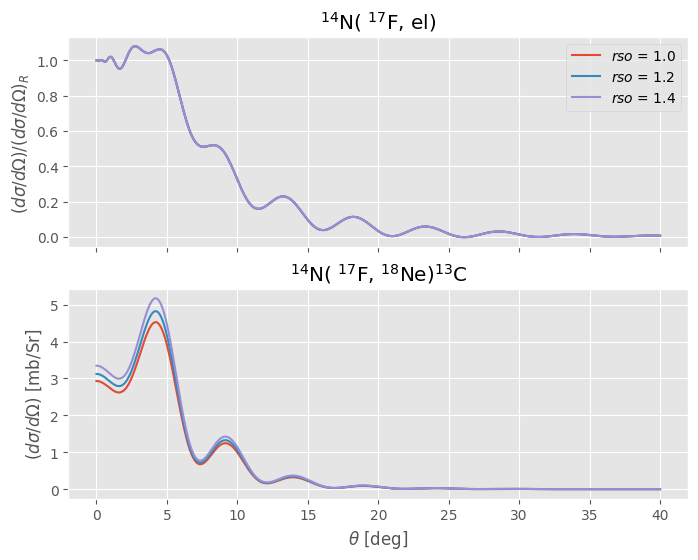

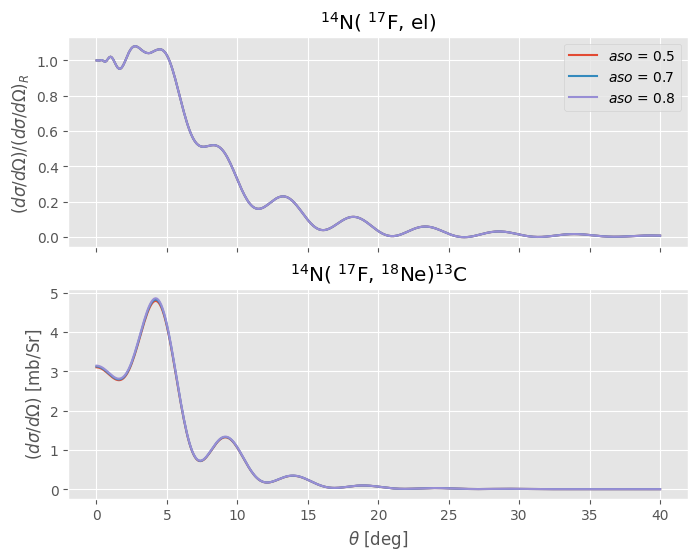

In [25]:
for param_name, values in tqdm(params_to_perturb.items()):
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
    disp_name = param_name.split("_")[0]
    axes[0].set_title("$^{14}$N( $^{17}$F, el)")
    axes[1].set_title("$^{14}$N( $^{17}$F, $^{18}$Ne)$^{13}$C")
    for val, result in zip(params_to_perturb[param_name], results[param_name]):
        axes[0].plot(
            result["channel_1"]["Theta_deg"],
            result["channel_1"]["sigma_mb_sr"],
            label=f"${disp_name}$ = {val:1.1f}",
        )
        axes[1].plot(
            result["channel_2"]["Theta_deg"],
            result["channel_2"]["sigma_mb_sr"],
            label=f"${disp_name}$ = {val:1.1f}",
        )

    axes[0].legend()
    axes[1].set_xlabel(r"$\theta$ [deg]")
    axes[0].set_ylabel(r"$(d\sigma/d\Omega) / (d\sigma/d\Omega)_R$ ")
    axes[1].set_ylabel(r"$(d\sigma/d\Omega)$ [mb/Sr]")

Naturally, the p + $^{17}$F potential has no effect on the elastic scattering (at least in the DWBA used here). On the other hand, the range and diffuseness of the real, central potential have a huge impact on the transfer cross section.

# Transfer to $^{18}$Ne(3.376 MeV, $4^+$) state

In [this paper](http://dx.doi.org/10.1016/j.nuclphysa.2004.09.054), measurement of $^{14}$N( $^{17}$F, $^{18}$Ne)$^{13}$C with transfer of the $d_{5/2}$ proton to the $^{18}$Ne(3.376 MeV, $4^+$) state is reported, with the results available on [EXFOR here](https://www-nds.iaea.org/exfor/servlet/X4sGetSubent?reqx=2507&subID=121137003&plus=1). 

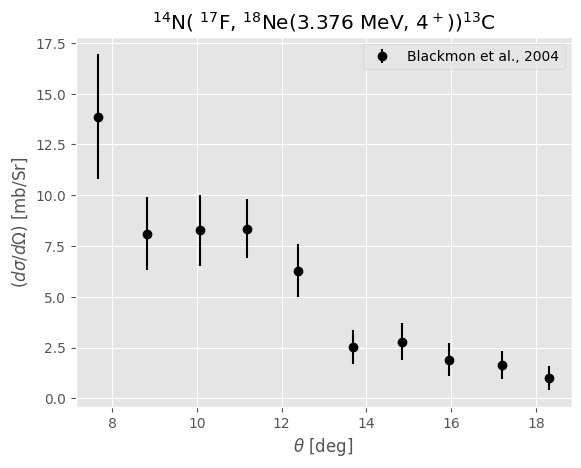

In [26]:
experimental_data = pd.read_csv(
    EXAMPLE_DIR / "blackmon_etal.csv",
    sep=r"\s+",
    skiprows=2,
    names=["Theta_deg", "sigma_mb_sr", "err_sigma_mb_sr"],
)
plt.errorbar(
    experimental_data["Theta_deg"],
    experimental_data["sigma_mb_sr"],
    experimental_data["err_sigma_mb_sr"],
    linestyle="none",
    color="k",
    marker="o",
    label="Blackmon et al., 2004",
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$(d\sigma/d\Omega)$ [mb/Sr]")
plt.title("$^{14}$N( $^{17}$F, $^{18}$Ne(3.376 MeV, $4^+$))$^{13}$C")
plt.legend()

## Frescox input for $^{14}$N( $^{17}$F, $^{18}$Ne(3.376 MeV, $4^+$))$^{13}$C

=
To modify our frescox template for this particular reaction, we will change a few lines:

1. specify the 4+ state at 3.376 MeV in the $^{18}$Ne mass partition, rather than the ground state
```fortran
&PARTITION namep='ne18' massp=18. zp=10 namet='c13' masst=13. zt=6 qval=3.6286 nex=1 /
&STATES jp=4. bandp=1 ep=3.376 cpot=2 jt=0.5 bandt=-1 et=0.0000 /
```

2. Change the $^{18}$Ne proton-binding overlap from the ground-state separation energy to the 4+ state separation energy:

\begin{equation}
    B_p(^{18}\text{Ne}, E_x = 3.376) \approx S_p(^{18}\text{Ne}) - E_x = 3.922 - 3.376 = 0.546 \text{ MeV}
\end{equation}

```fortran
&Overlap kn1=1 ic1=1 ic2=2 in=1 kind=0 nn=1 l=2 sn=0.5 j=2.5 kbpot=3 be=0.546 isc=1 ipc=0 /
```

We've written this file for you; let's test it out!

In [27]:
NE_EX3_INPUT_FILE_PATH = Path("./Transfer_template/B5-18neon_4+_tr.in")

In [28]:
# Create the frescox input file by filling in the user-defined template with parameters
cfg = bfrescox.Configuration.from_template(
    NE_EX3_INPUT_FILE_PATH,
    EXAMPLE_DIR.joinpath("frescox.in"),
    {},
    overwrite=True,
)

In [29]:
%%time
bfrescox.run_simulation(
    cfg, EXAMPLE_DIR.joinpath("frescox.out"), cwd=EXAMPLE_DIR, overwrite=True
)

CPU times: user 1.34 ms, sys: 1.94 ms, total: 3.28 ms
Wall time: 30.3 s


In [30]:
results = bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
results.keys()

dict_keys(['channel_1', 'channel_2'])

Text(0, 0.5, '$d\\sigma/d\\Omega$ [mb/Sr]')

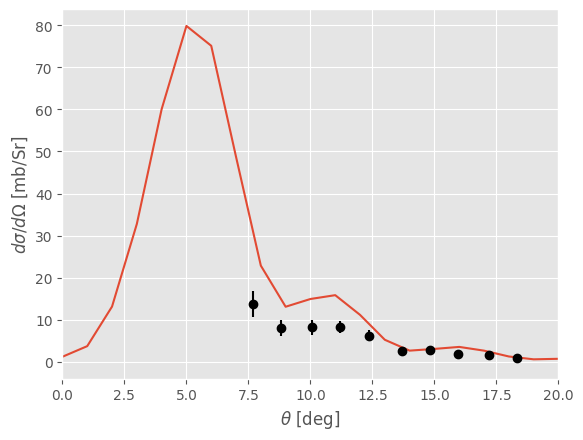

In [31]:
plt.plot(
    results["channel_2"]["Theta_deg"],
    results["channel_2"]["sigma_mb_sr"],
    label="Frescox",
)
plt.errorbar(
    experimental_data["Theta_deg"],
    experimental_data["sigma_mb_sr"],
    experimental_data["err_sigma_mb_sr"],
    linestyle="none",
    color="k",
    marker="o",
    label="Blackmon et al., 2004",
)


plt.xlim([0, 20])
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$d\sigma/d\Omega$ [mb/Sr]")

Note that the theory prediction, which assumes the spectroscopic factor of the $d_{5/2}$ proton in  $^{18}$Ne(3.376 MeV, $4^+$) is 1, is only slightly higher than the experimental value. This implies the actual spectroscopic factor is indeed close to 1, implying the $d_{5/2}$ proton state is sharply peaked at 3.376 MeV, rather than being fragmented by many-body correlations.

## Parameter sweep for the  $^{14}$N( $^{17}$F, $^{18}$Ne(3.376 MeV, $4^+$))$^{13}$C reaction

We've also made a template with the same parameters as the previous one, but for this reaction. We will use it as before to do a parameter sweep of the p + $^{17}$F interaction parameters.


In [32]:
NE_EX3_TEMPLATE_FILE_PATH = Path("./Transfer_template/B5-18neon_4+_tr.template")

In [33]:
# this template has the same params except for the binding energy ones, which we fix
del base_params["BE_p_13C"]
del base_params["BE_p_17F"]

In [34]:
params_to_perturb = {
    "r_p17F": [1.0, 1.2, 1.4],
    "a_p17F": [0.5, 0.65, 0.8],
}

In [35]:
results = {}
for param_name, values in tqdm(params_to_perturb.items()):
    results[param_name] = []
    for val in values:
        params = base_params.copy()
        params[param_name] = val
        cfg = bfrescox.Configuration.from_template(
            NE_EX3_TEMPLATE_FILE_PATH,
            EXAMPLE_DIR.joinpath("frescox.in"),
            params,
            overwrite=True,
        )
        bfrescox.run_simulation(
            cfg, EXAMPLE_DIR.joinpath("frescox.out"), cwd=EXAMPLE_DIR, overwrite=True
        )
        results[param_name].append(
            bfrescox.parse_fort16(EXAMPLE_DIR.joinpath("fort.16"))
        )

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [02:57<00:00, 88.98s/it]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 88.04it/s]


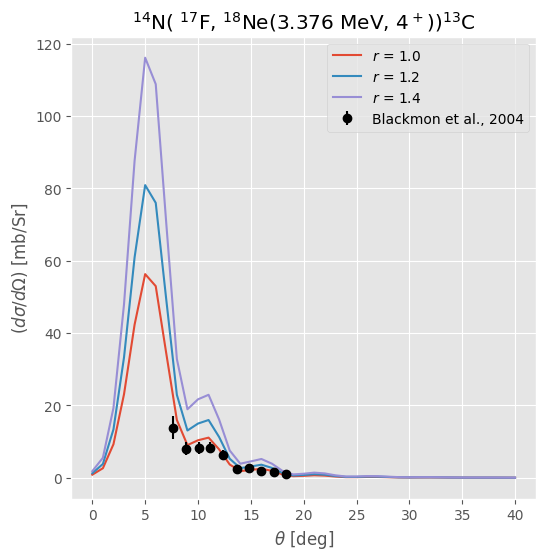

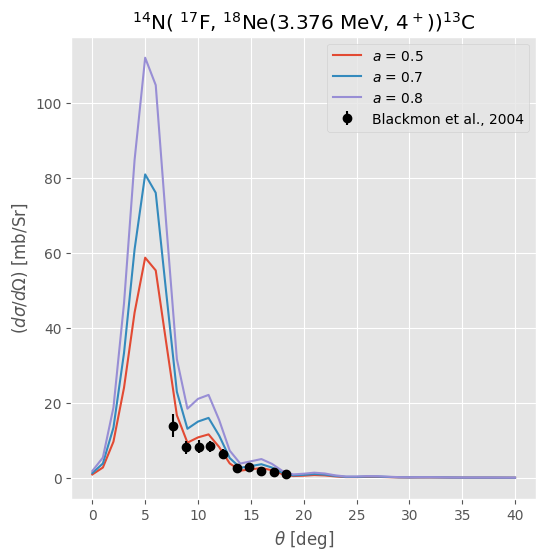

In [36]:
for param_name, values in tqdm(params_to_perturb.items()):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    disp_name = param_name.split("_")[0]
    ax.set_title("$^{14}$N( $^{17}$F, $^{18}$Ne(3.376 MeV, $4^+$))$^{13}$C")
    for val, result in zip(params_to_perturb[param_name], results[param_name]):
        ax.plot(
            result["channel_2"]["Theta_deg"],
            result["channel_2"]["sigma_mb_sr"],
            label=f"${disp_name}$ = {val:1.1f}",
        )
    plt.errorbar(
        experimental_data["Theta_deg"],
        experimental_data["sigma_mb_sr"],
        experimental_data["err_sigma_mb_sr"],
        linestyle="none",
        color="k",
        marker="o",
        label="Blackmon et al., 2004",
    )

    ax.legend()
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_ylabel(r"$(d\sigma/d\Omega)$ [mb/Sr]")

Note that the optical model parameters significantly effect the prediction! If one were using a phenomenological potential to extract spectroscopic factors, one should be careful about the uncertainty due to the optical potential.